In [19]:
snnapdatapath = "/media/udickman/uri-external-drive/SNNAP_data/fig10"
datapath = "/home/udickman/Desktop/projects/CWRU/neuronpyxl/Dickman_etal_2025_Figures/Data"
excelpath = "../Excel_files"
figpath = "../figs"
fig_prefix = "Dickman_etal_Results"
excelfile = "fig10.xlsx"

# Run this cell, then comment out the lines below and restart the kernel.
# You can even save the data into a file from here by running the run_sim command from the ipynb kernel
# import os
# !yes | neuronpyxl -f gen_mods --file {os.path.join(excelpath,excelfile)}
# !yes | neuronpyxl -f run_sim --file {os.path.join(excelpath,excelfile)} --name BMP --duration 75000 --teq 10000 --vonly --folder fig10data

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.lines import Line2D
import scienceplots
import numpy as np
import pandas as pd
import os
import sys
plt.style.use(["no-latex", "notebook"])

legend_labels = {"forestgreen": "Control",
                 "orangered": "Protraction",
                 "purple": "Closure",
                 "teal": "Retraction",
                 "black": "Retraction terminating"
                }

colors = {
    "forestgreen": ["CBI2"], # command-like neuron
    "orangered": ["B20", "B30", "B31a", "B34", "B35", "B40", "B63"], # protraction
    "purple": ["B8"], # closure
    "teal": ["B51a", "B64a","B4"], # retraction
    "black": ["B52"] # retraction termination
}
# colors = {
#     "forestgreen": ["CBI2"], # command-like neuron
#     "orangered": ["B31a"], # protraction
#     "purple": ["B8"], # closure
#     "teal": ["B4"], # retraction
#     "black": ["B52"] # retraction termination
# }

all_cells = [(cell, color) for color, cells in colors.items() for cell in cells]
num_cells = len(all_cells)
    
file = pd.HDFStore(os.path.join(datapath,"fig10data/BMP_data.h5"))
data = file["membrane"]
data["t"] /= 1000

snnap_data = pd.read_csv(os.path.join(snnapdatapath,"BMP_clean.smu.out"), sep="\t", header=None).dropna(axis=1)
snnap_data.columns = ["t", "V_CBI2", "V_B31a", "V_B20", "V_B30", "V_B40", "V_B34", "V_B35",
                      "V_B63", "V_B4", "V_B8", "V_B51a", "V_B64a", "V_B52"]

# xlim = (10,50)
import matplotlib.ticker as ticker
def xtickson(ax,ticks):
    ax.tick_params(axis='x', which='both', bottom=True, top=False)

    # Specify number of ticks on x-axis
    ax.set_xticks(ticks)

def ylabel(ax,text):
    ax.text(-0.05, 0.5, text, transform=ax.transAxes,
        rotation=0, va='center', ha='center', fontsize=18)

def plot_bmps(data,axs,all_cells,xlim=(0,65),snnap=True,ylab=False):
    if num_cells == 1:
        axs = [axs]  # Ensure axes is a list when there's only one subplot

    # Plot data from each cell
    for ax, (cell, color) in zip(axs, all_cells):
        t = np.array(data["t"])
        if snnap:
            ind = np.where(t > 10)[0]
            t = np.array(t[ind])
            t -= t[0]
            V = data[f"V_{cell}"][ind]
        else:
            V = data[f"V_{cell}"]
        
        ax.plot(t, V, color=color, linewidth=1,label=None)
        ax.spines['left'].set_visible(False)
        ax.set_yticks([])
        ax.set_xlim(xlim)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.set_xticks([])
        if ylab:
            ylabel(ax,cell)

In [9]:
def plot_vertical_scalebar(ax,scalebar_length=100,bar_width=0.25,xoffset=0,yoffset=0):
    from matplotlib.patches import Rectangle
    # Get axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Coordinates for bottom-right corner
    x_start = xlim[1] + xoffset - bar_width
    y_start = ylim[0] + yoffset

    scalebar = Rectangle((x_start, y_start), width=bar_width, height=scalebar_length,
                        color='black', linewidth=0, zorder=10)

    ax.add_patch(scalebar)

    # Optional: Add text label
    ax.text(x_start - 1, y_start + scalebar_length / 2, f'{scalebar_length} mV',
            va='center', ha='right', color='black', fontsize=16)

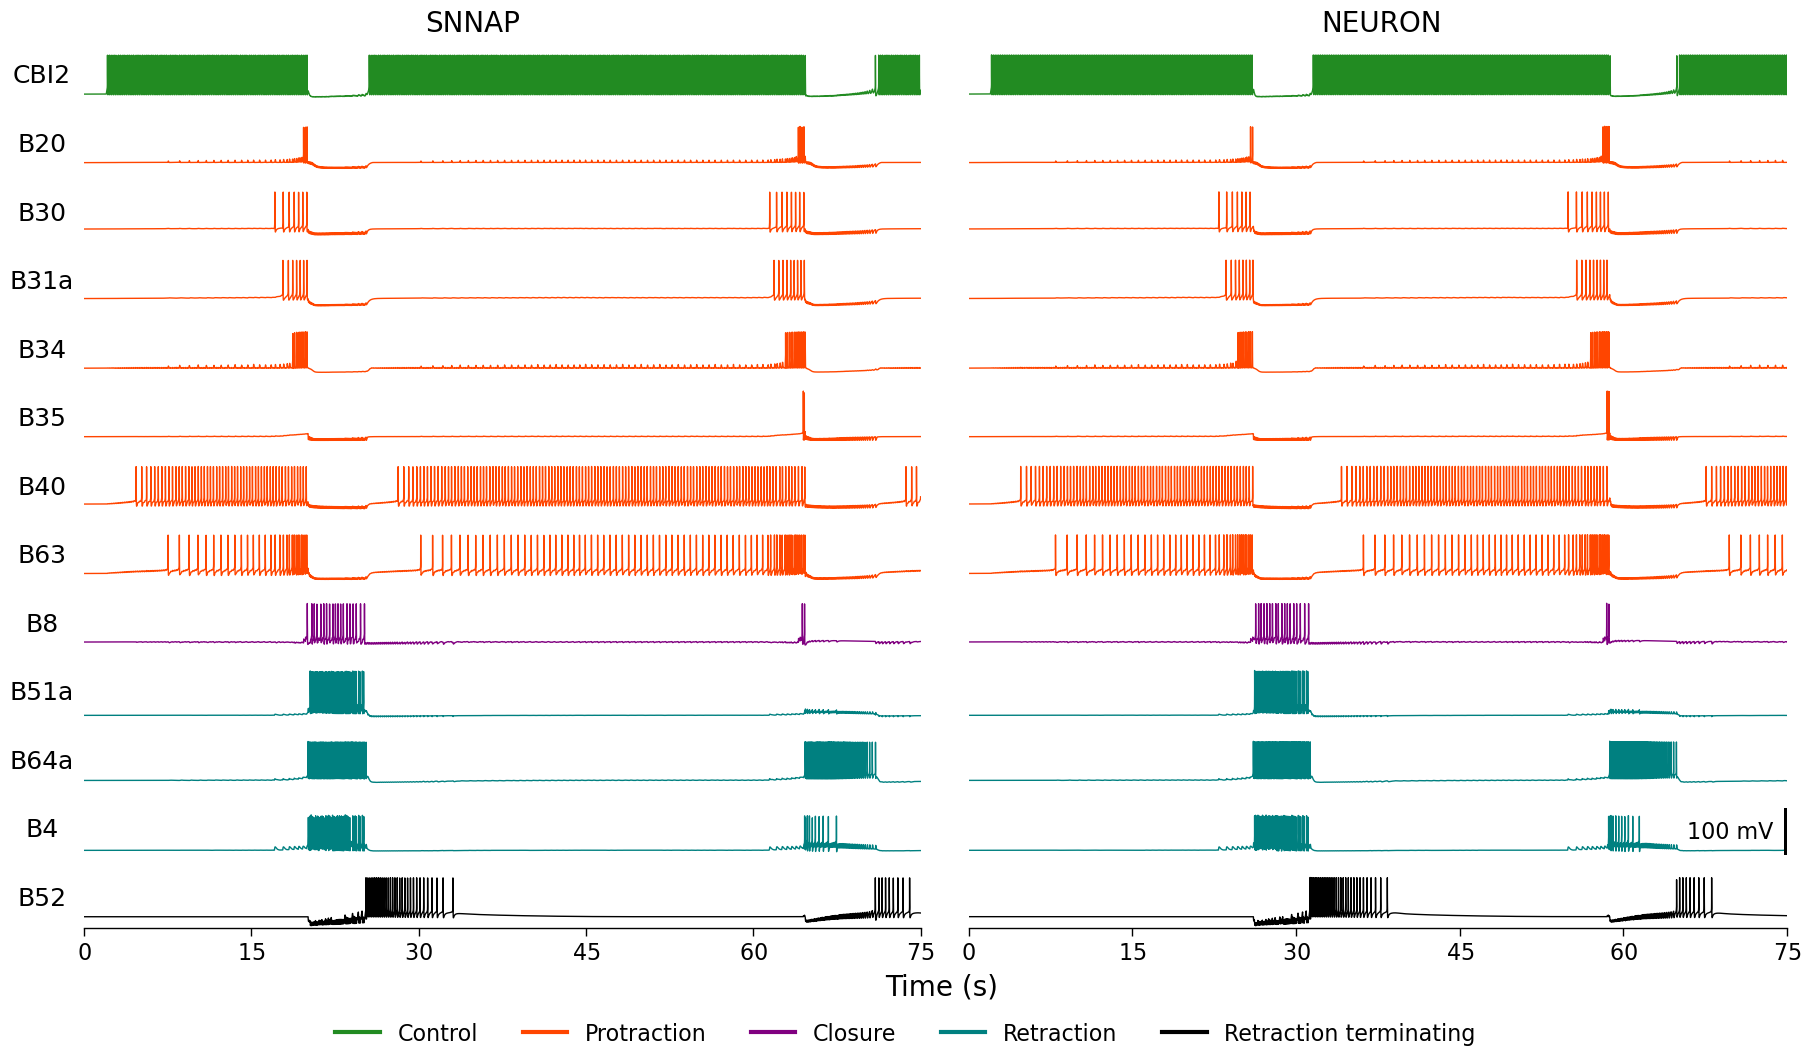

In [16]:
# Create figure
xlim = (0,75)

    
fig = plt.figure(figsize=(18,10),constrained_layout=True)
sfigs = fig.subfigures(1,2, width_ratios=(1.1,1))
ax1 = sfigs[0].subplots(num_cells,1,sharey=True)
ax2 = sfigs[1].subplots(num_cells,1,sharey=True)    

plot_bmps(snnap_data,ax1,all_cells, xlim,True,True)
plot_bmps(data,ax2,all_cells,xlim,False,False)

ax1[-1].spines['bottom'].set_visible(True)
xtickson(ax1[-1],np.linspace(0,75,num=6,dtype=int))

ax2[-1].spines['bottom'].set_visible(True)
xtickson(ax2[-1],np.linspace(0,75,num=6,dtype=int))

sfigs[0].suptitle("SNNAP",fontsize=20)
sfigs[1].suptitle("NEURON",fontsize=20)

# fig.suptitle("Momohara 2022 Network",fontsize=20)
fig.supxlabel("Time (s)",fontsize=20,x=0.52)

handles, labels = plt.gca().get_legend_handles_labels()
extension = []
for c, label in legend_labels.items():
    extension.append(Line2D([0], [0], label=label, color=c, linewidth=3))
handles.extend(extension)

fig.legend(handles=handles,loc='lower center',frameon=False,fancybox=False, 
           shadow=False,ncol=5,bbox_to_anchor=(0.5, -0.06))

plot_vertical_scalebar(ax2[-2],bar_width=0.3,yoffset=10,xoffset=0)

plt.show()
fig.savefig(os.path.join(figpath,f"{fig_prefix}_full_network.jpg"), bbox_inches='tight', dpi=300)